# Step 1: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Step 2: Load and Explore Dataset

In [6]:
# Load the dataset
df = pd.read_csv("Car_Prices_Dataset.csv")

# Display the first few rows of the dataset
print(df.head())

# Check for missing values
print(df.isnull().sum())

# Summary statistics
print(df.describe())

# Check data types
print(df.dtypes)

      Brand     Model  Year  Engine Size (cc)  Mileage (km) Fuel Type  \
0       BMW    Tucson  2002              2749         48717    Diesel   
1  Mercedes     Camry  2000              1652        104603  Electric   
2       BMW     Camry  2007              1022        259602    Hybrid   
3    Nissan  3-Series  2014              3497        258962    Diesel   
4    Toyota      CX-5  2004              4138        285636  Electric   

  Transmission  Price  
0    Automatic  25317  
1       Manual  30803  
2       Manual  71431  
3    Automatic  44394  
4    Automatic  97969  
Brand               0
Model               0
Year                0
Engine Size (cc)    0
Mileage (km)        0
Fuel Type           0
Transmission        0
Price               0
dtype: int64
              Year  Engine Size (cc)   Mileage (km)         Price
count   100.000000         100.00000     100.000000    100.000000
mean   2011.120000        2944.54000  148553.390000  54663.160000
std       6.867108        1126

In [ ]:
# Step 3: Preprocess Data

3.1 Convert Categorical Variables

In [8]:
# Convert categorical variables into numeric format
df = pd.get_dummies(df, columns=['Brand', 'Model', 'Fuel Type', 'Transmission'], drop_first=True)

# Display the transformed dataset
print(df.head())

   Year  Engine Size (cc)  Mileage (km)  Price  Brand_Ford  Brand_Honda  \
0  2002              2749         48717  25317       False        False   
1  2000              1652        104603  30803       False        False   
2  2007              1022        259602  71431       False        False   
3  2014              3497        258962  44394       False        False   
4  2004              4138        285636  97969       False        False   

   Brand_Hyundai  Brand_Mazda  Brand_Mercedes  Brand_Nissan  ...  \
0          False        False           False         False  ...   
1          False        False            True         False  ...   
2          False        False           False         False  ...   
3          False        False           False          True  ...   
4          False        False           False         False  ...   

   Model_C-Class  Model_CX-5  Model_Camry  Model_Civic  Model_Focus  \
0          False       False        False        False        False  

3.2 Handle Missing Values

In [10]:
# Fill missing values (if any)
df.fillna(df.mean(), inplace=True)

# Step 4: Split Data into Training and Testing Sets

In [12]:
# Define independent variables (features) and dependent variable (target)
X = df.drop(columns=['Price'])  # Features
y = df['Price']  # Target variable

# Split data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display dataset shapes
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(80, 21) (20, 21) (80,) (20,)


# Step 5: Train a Regression Model

In [14]:
# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Check model coefficients
coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print(coefficients)

                      Coefficient
Year                   428.509444
Engine Size (cc)         3.099321
Mileage (km)             0.125515
Brand_Ford           -4949.319078
Brand_Honda            702.908335
Brand_Hyundai        -6373.203615
Brand_Mazda           -685.154077
Brand_Mercedes       -8396.652234
Brand_Nissan         10065.569892
Brand_Toyota         -3241.783753
Model_Altima          -397.839539
Model_C-Class        -4670.346695
Model_CX-5           14202.058987
Model_Camry          15220.724841
Model_Civic          12571.846110
Model_Focus          13726.922898
Model_Tucson         -3314.190148
Fuel Type_Electric    2672.538311
Fuel Type_Hybrid      7983.220357
Fuel Type_Petrol     -6300.108978
Transmission_Manual  -2523.931176


# Step 6: Make Predictions

In [16]:
# Predict on test data
y_pred = model.predict(X_test)

# Compare actual vs predicted prices
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(results.head())

    Actual     Predicted
83   63525  37805.866437
53   41368  58962.609292
70   34606  28958.551433
45   52185  48316.432792
44   71998  49774.441173


# Step 7: Evaluate Model Performance

In [18]:
# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R-Squared: {r2}")

Mean Absolute Error: 24011.607143070847
Mean Squared Error: 871793090.7779983
Root Mean Squared Error: 29526.142497420795
R-Squared: -0.1743945698293603


# Step 8: Visualize Results

8.1 Scatter Plot of Actual vs Predicted Prices

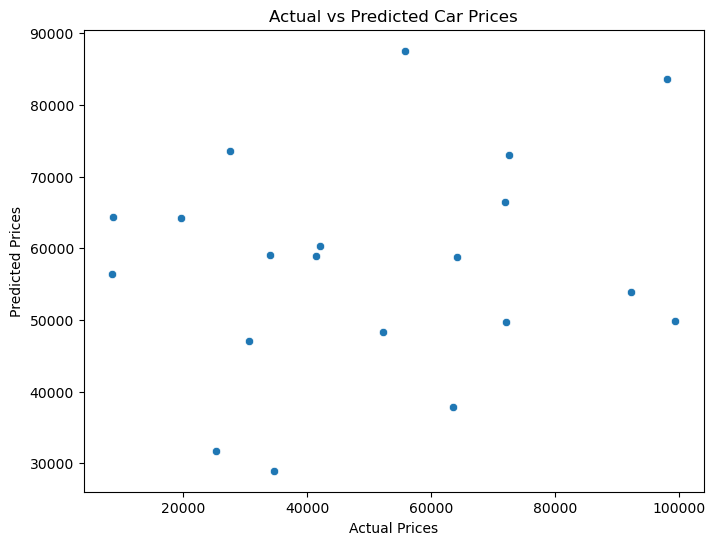

In [20]:
# Plot actual vs predicted prices
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Car Prices")
plt.show()

8.2 Residual Plot

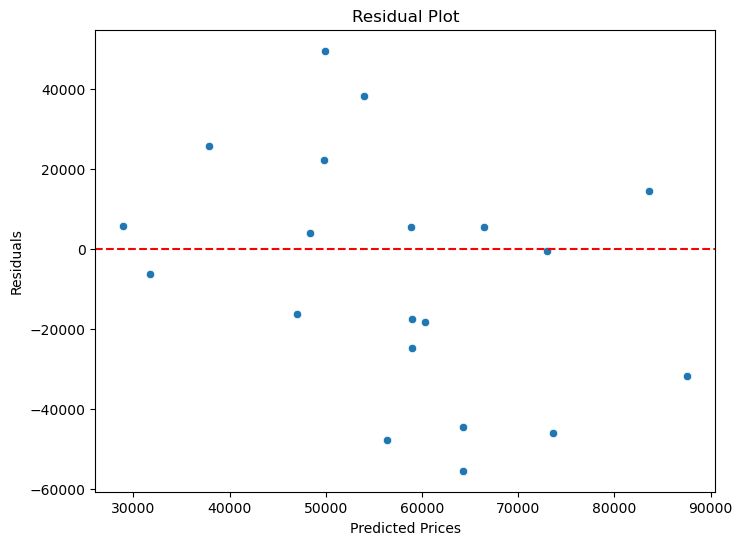

In [22]:
# Residual plot
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Prices")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

# Step 9: Allow User Input to Predict Car Prices

In [ ]:
# Function to take user input and predict car price
def predict_car_price():
    print("Enter details of the car:")
    year = int(input("Enter year of manufacture: "))
    engine_size = float(input("Enter engine size (cc): "))
    mileage = float(input("Enter mileage (km): "))
    
    # List of possible fuel types and transmission types
    fuel_types = ['Petrol', 'Diesel', 'Hybrid', 'Electric']
    transmission_types = ['Manual', 'Automatic']
    
    fuel_type = input(f"Enter fuel type from {fuel_types}: ")
    transmission = input(f"Enter transmission type from {transmission_types}: ")
    
    # Create input dataframe
    input_data = pd.DataFrame([[year, engine_size, mileage]], columns=['Year', 'Engine Size', 'Mileage'])
    
    # Add fuel type and transmission columns (one-hot encoding as in training data)
    for ft in fuel_types:
        input_data[f'Fuel Type_{ft}'] = 1 if ft == fuel_type else 0
    
    for tr in transmission_types:
        input_data[f'Transmission_{tr}'] = 1 if tr == transmission else 0
    
    # Load trained model
    model = joblib.load('car_price_model.pkl')
    
    # Predict car price
    predicted_price = model.predict(input_data)[0]
    print(f"Predicted Car Price: ${predicted_price:.2f}")

# Call function to predict car price
predict_car_price()

Enter details of the car:


# Self-Reflective Questions and Conclusion

In [ ]:
print("""
Self-Reflective Questions for Students:

1. Which car attributes have the highest impact on price?
   - Use a correlation matrix to identify features like Year, Engine Size, and Mileage that strongly influence car prices.

2. How does the car's age affect its price?
   - Plot a graph of Year vs. Price to analyze depreciation trends.

3. Does mileage have a significant effect on car prices?
   - Visualize the relationship between Mileage and Price to see how higher mileage reduces car prices.

4. How does the choice of fuel type influence car prices?
   - Compare average prices across different fuel types (Petrol, Diesel, Hybrid, Electric).

5. Can the model accurately predict prices for luxury brands vs. economy brands?
   - Analyze model accuracy for brands like BMW/Mercedes (luxury) vs. Toyota/Honda (economy).

Conclusion:
In this case study, a regression model was built to predict car prices based on various attributes. The model's performance can be evaluated using metrics like R-squared, MAE, and RMSE. To improve the model, consider:
Collecting more data by using advanced regression techniques like Random Forest or Gradient Boosting and performing feature engineering to create more meaningful features.
""")